# День 08. Упражнение 05
# Кластеризация

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

## 1. Предобработка

1. Прочитай файл [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) в DataFrame.
2. Удали колонку `pageviews`, мы будем кластеризовать пользователей только по количеству коммитов и их средней разнице.

In [2]:
df = pd.read_csv('../data/regression.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     str    
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.0 KB


In [3]:
df = df.drop('pageviews', axis=1)
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `random_state=21` и `n_clusters=3`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

In [4]:
X = df[['num_commits', 'AVG(diff)']].values

In [5]:
km = KMeans(n_clusters=3, random_state=21)
km.fit(X)
labels = km.labels_
df['KM_cluster'] = labels
score = silhouette_score(X, labels)
print(f"Коэффициент силуэта: {score:.2f}")
centers = km.cluster_centers_

Коэффициент силуэта: 0.45


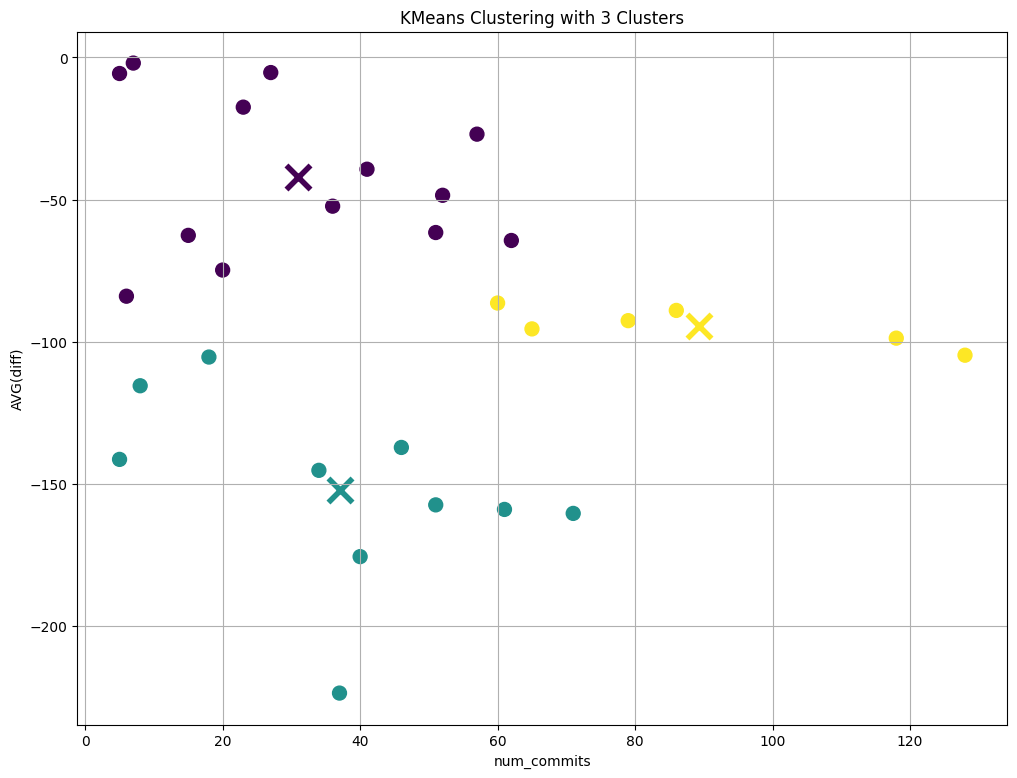

In [6]:
plt.figure(figsize=(12,9))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, label='Пользователи')
colormap = plt.colormaps['viridis']
colors = colormap(np.linspace(0, 1, km.n_clusters))
for i, center in enumerate(centers):
    plt.scatter(
        center[0],
        center[1],
        color=colors[i],
        marker='x',
        s=300,
        linewidths=4,
        label=f'Центр кластера {i}'
    )

plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('KMeans Clustering with 3 Clusters')
plt.grid(True)
plt.show()


====== n_clusters = 2 ======
Silhouette Score: 0.419
Centers:
[[  39.44444444  -56.33148148]
 [  54.45454545 -147.16818182]]


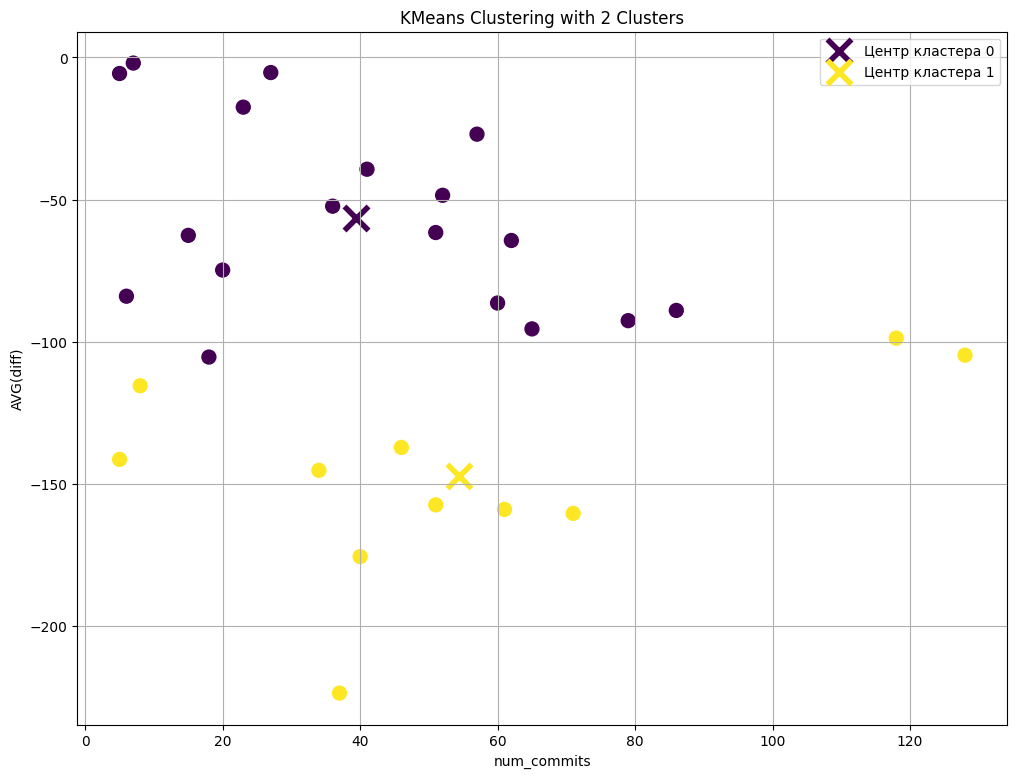


====== n_clusters = 3 ======
Silhouette Score: 0.445
Centers:
[[  30.92307692  -41.92820513]
 [  37.1        -152.075     ]
 [  89.33333333  -94.5       ]]


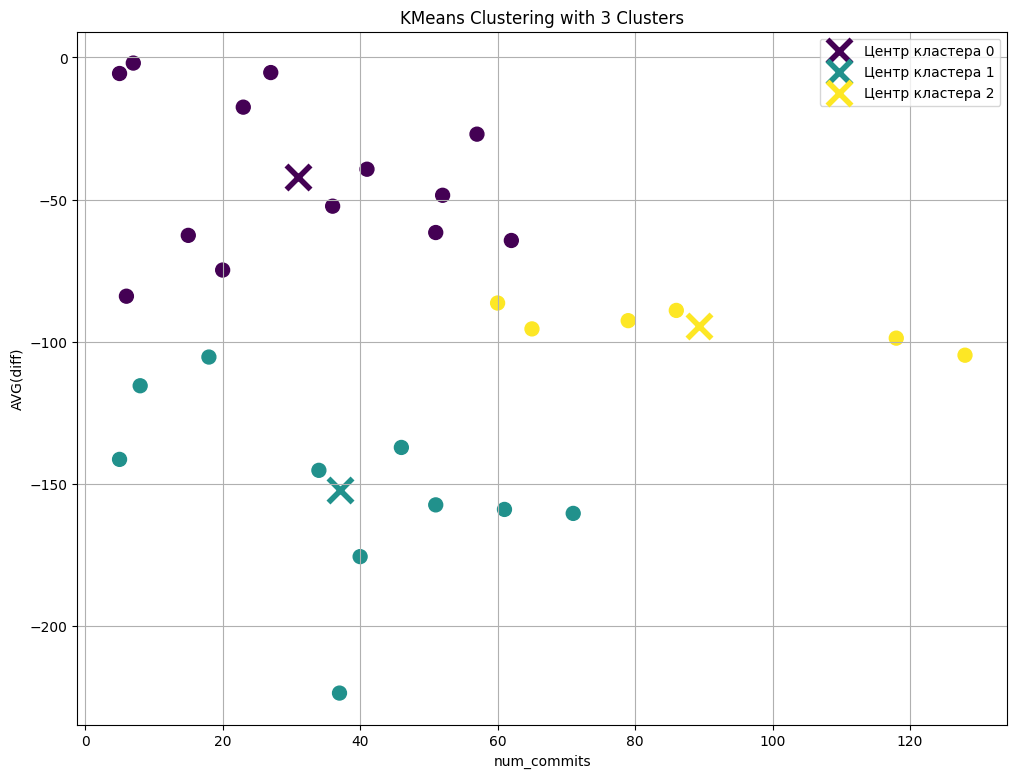


====== n_clusters = 4 ======
Silhouette Score: 0.415
Centers:
[[  33.          -38.42222222]
 [  52.         -175.2       ]
 [  89.33333333  -94.5       ]
 [  19.5        -121.45833333]]


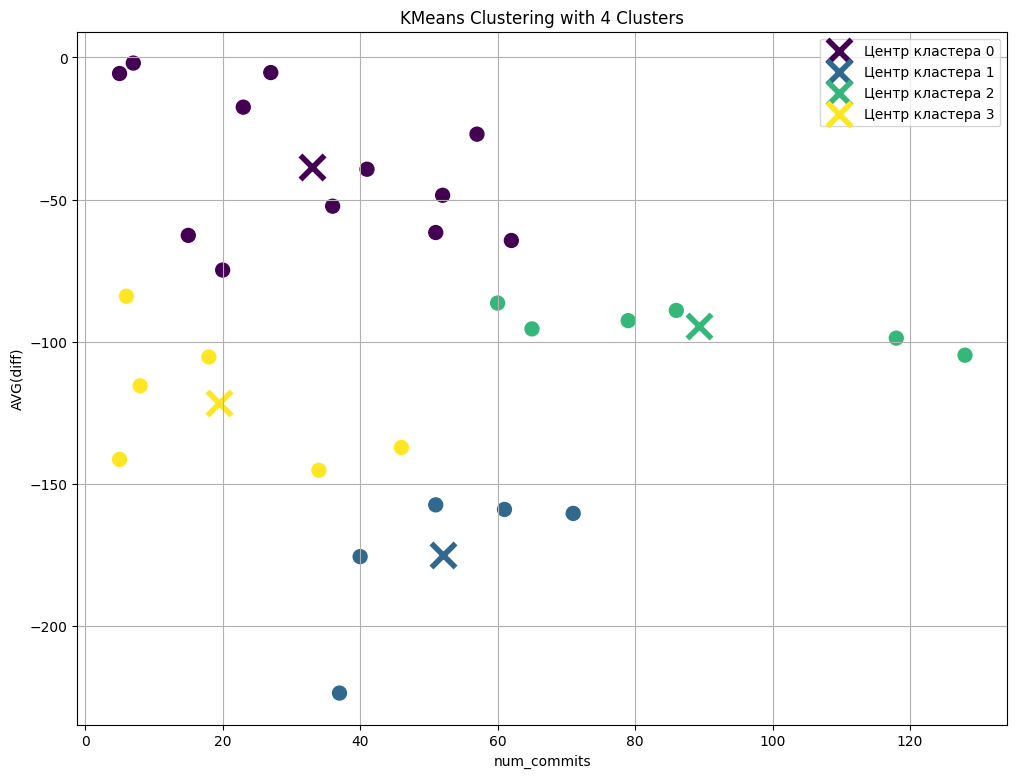


====== n_clusters = 5 ======
Silhouette Score: 0.352
Centers:
[[  40.77777778  -70.01481481]
 [  52.         -175.2       ]
 [ 102.75        -96.275     ]
 [  22.2        -128.95      ]
 [  26.66666667  -16.13888889]]


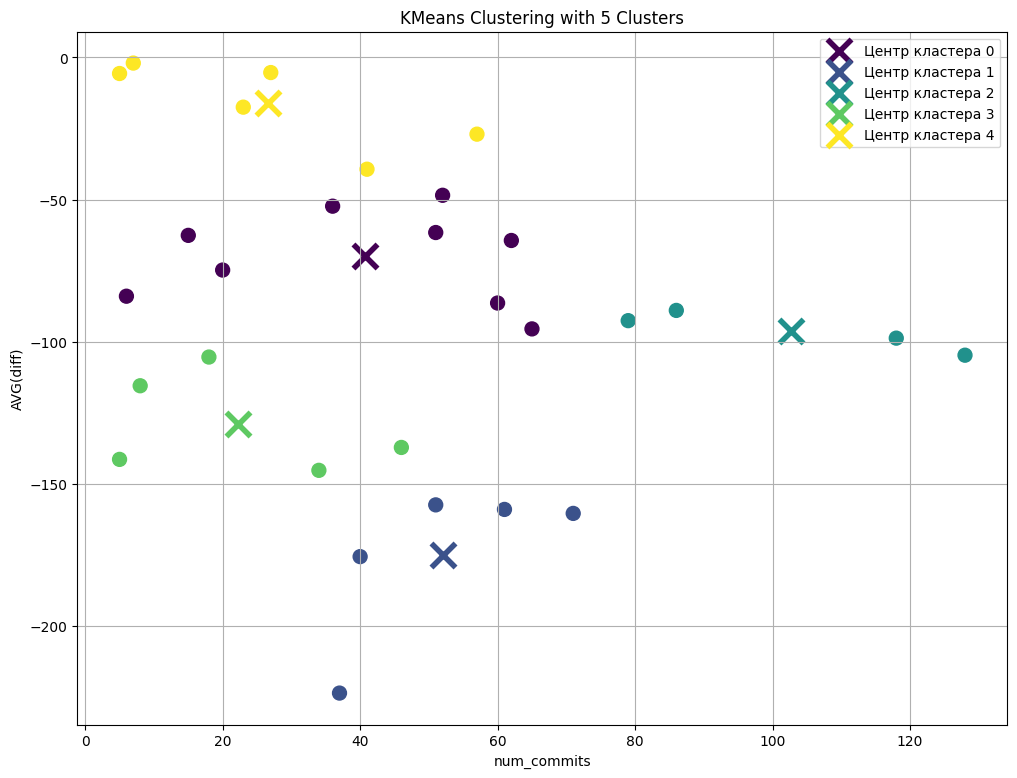

In [7]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=21)
    km.fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    score = silhouette_score(X, labels)
    
    print(f"\n====== n_clusters = {k} ======")
    print(f"Silhouette Score: {score:.3f}")
    print(f"Centers:\n{centers}")
    plt.figure(figsize=(12, 9))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100)
    
    colormap = plt.colormaps['viridis']
    colors = colormap(np.linspace(0, 1, k))
    for i, center in enumerate(centers):
        plt.scatter(center[0], center[1],
                    color=colors[i],
                    marker='x',
                    s=300,
                    linewidths=4,
                    label=f'Центр кластера {i}')
        
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.title(f'KMeans Clustering with {k} Clusters')
    plt.grid(True)
    plt.legend()
    plt.show()

## 3. DBSCAN

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `eps=20` и `min_samples=2`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `eps` и `min_samples` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

In [8]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels = dbscan.fit_predict(X)
df['DBS_cluster'] = labels

In [9]:
if len(set(labels)) > 1 and len(set(labels)) != 1 + (1 if -1 in labels else 0):
    score = silhouette_score(X, labels)
    print(f"Silhouette Score: {score:.3f}")
else:
    print("Silhouette Score не вычисляется, т.к. образовался один кластер или только шум.")

Silhouette Score: 0.383


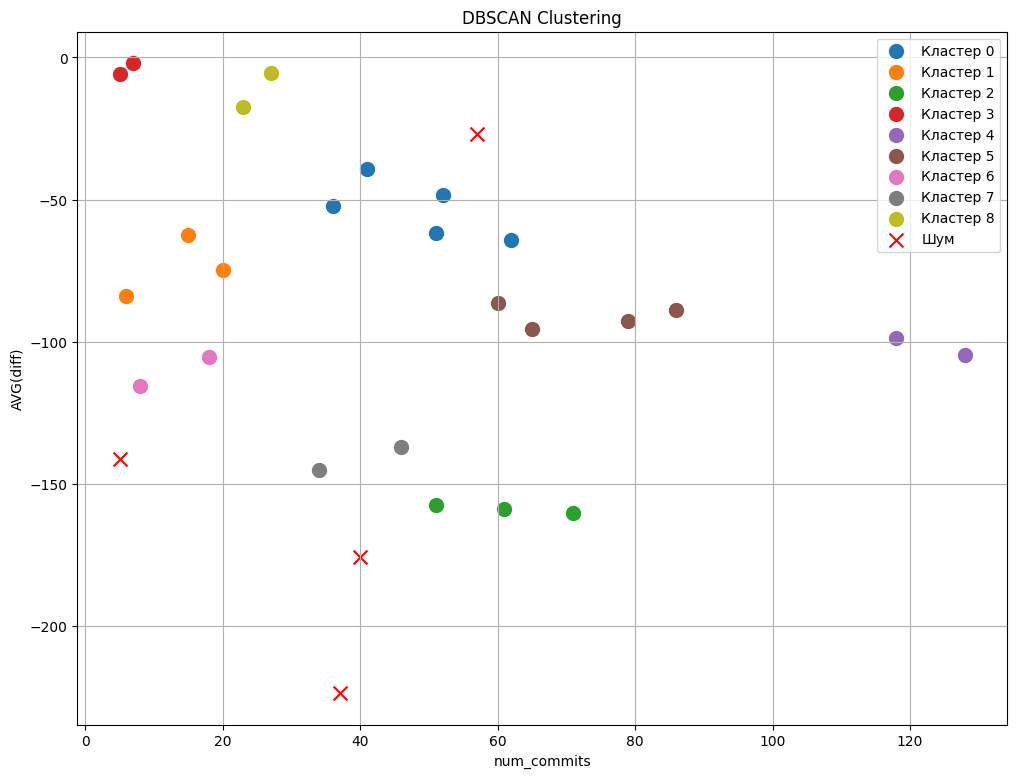

In [10]:
plt.figure(figsize=(12, 9))

unique_labels = set(labels)
colormap = plt.colormaps['viridis']
colors = colormap(np.linspace(0, 1, len(unique_labels)))

for k in unique_labels:
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    if k == -1:
        # Шум (noise)
        plt.scatter(xy[:, 0], xy[:, 1], c='red', marker='x', s=100, label='Шум')
    else:
        plt.scatter(xy[:, 0], xy[:, 1], s=100, label=f'Кластер {k}')

plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('DBSCAN Clustering')
plt.grid(True)
plt.legend()
plt.show()

eps=5, min_samples=2, clusters=1, noise=27, silhouette_score=N/A


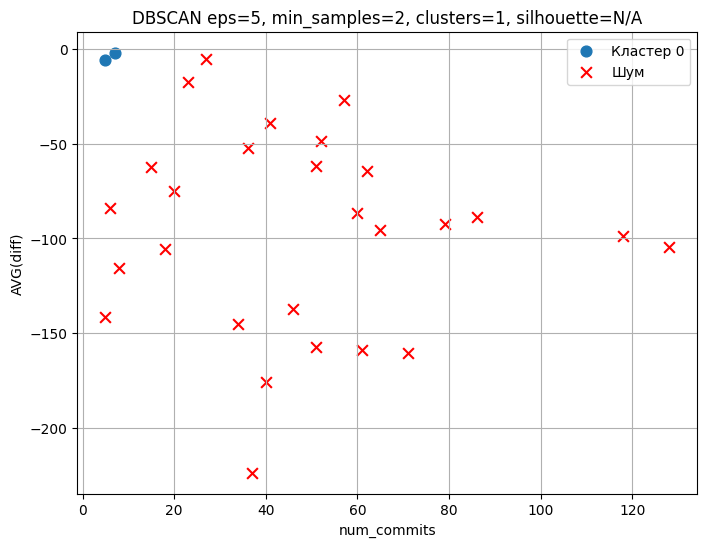

eps=5, min_samples=3, clusters=0, noise=29, silhouette_score=N/A


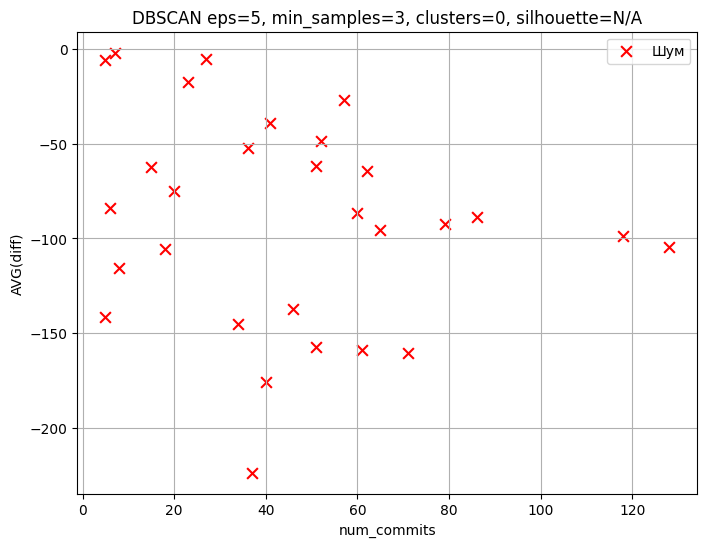

eps=5, min_samples=4, clusters=0, noise=29, silhouette_score=N/A


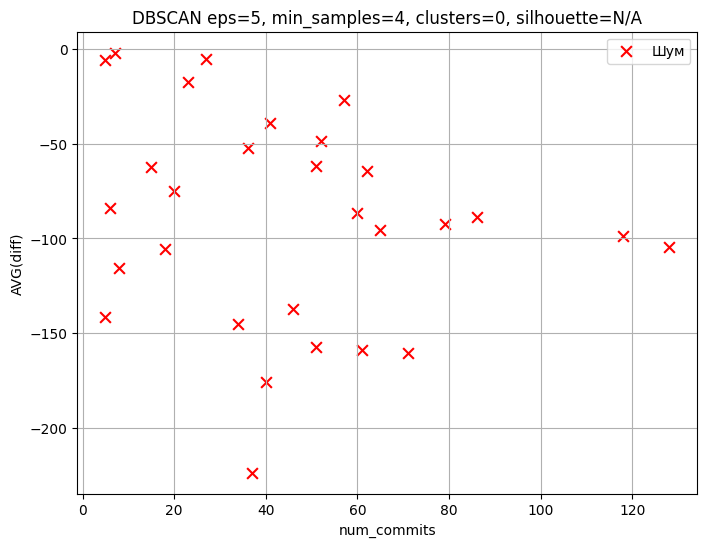

eps=5, min_samples=5, clusters=0, noise=29, silhouette_score=N/A


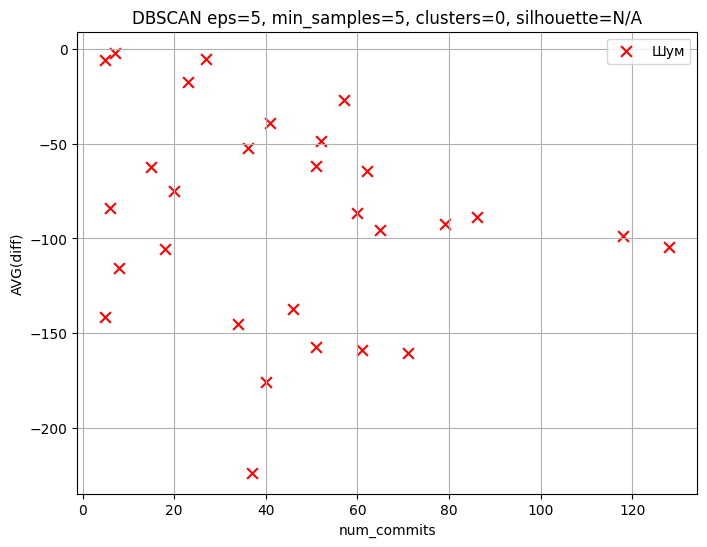

eps=10, min_samples=2, clusters=2, noise=25, silhouette_score=-0.079


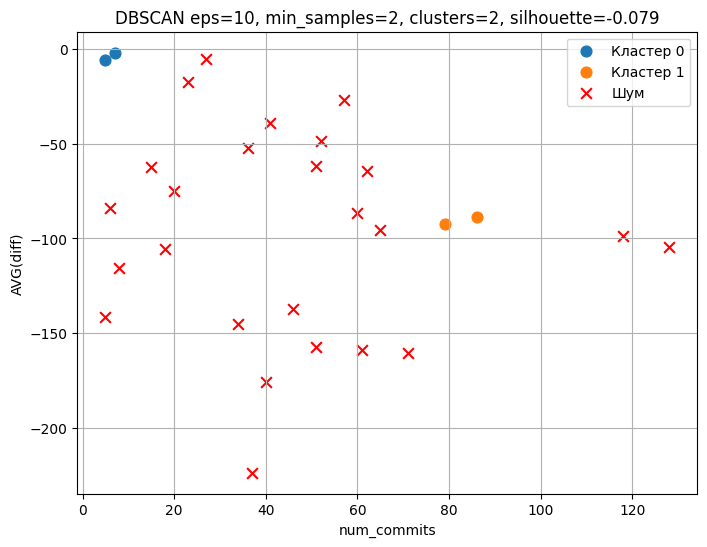

eps=10, min_samples=3, clusters=0, noise=29, silhouette_score=N/A


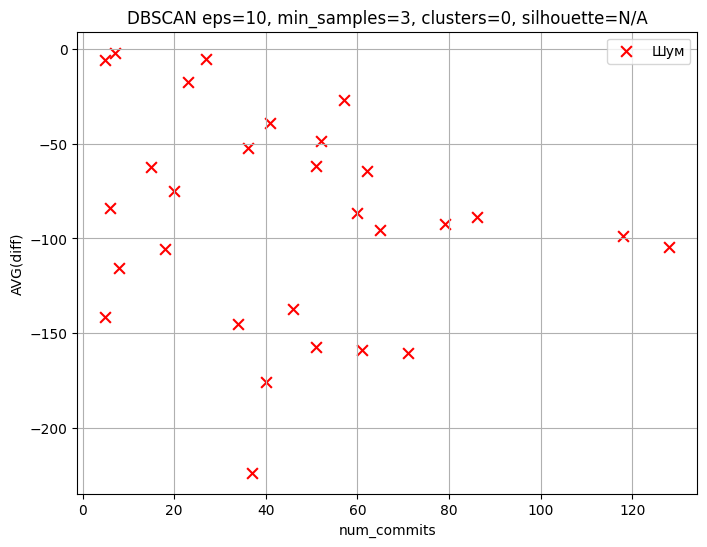

eps=10, min_samples=4, clusters=0, noise=29, silhouette_score=N/A


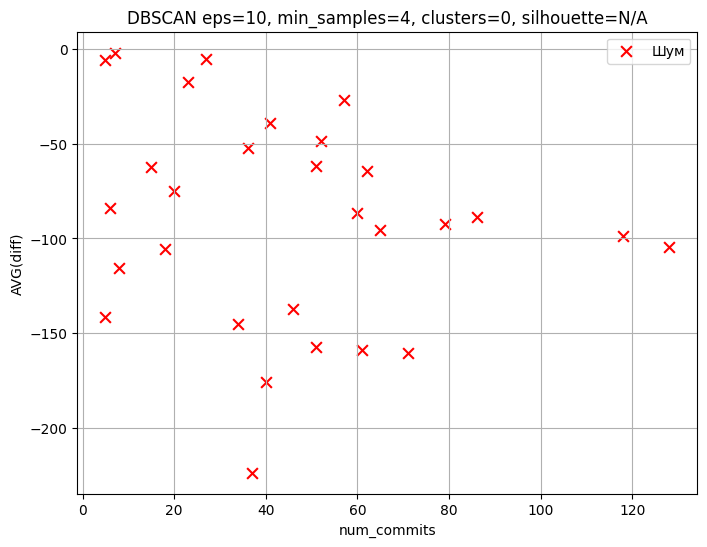

eps=10, min_samples=5, clusters=0, noise=29, silhouette_score=N/A


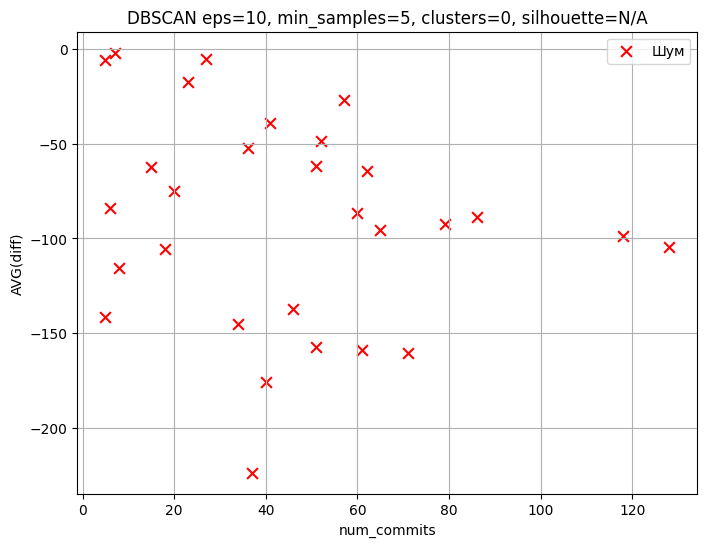

eps=15, min_samples=2, clusters=9, noise=5, silhouette_score=0.347


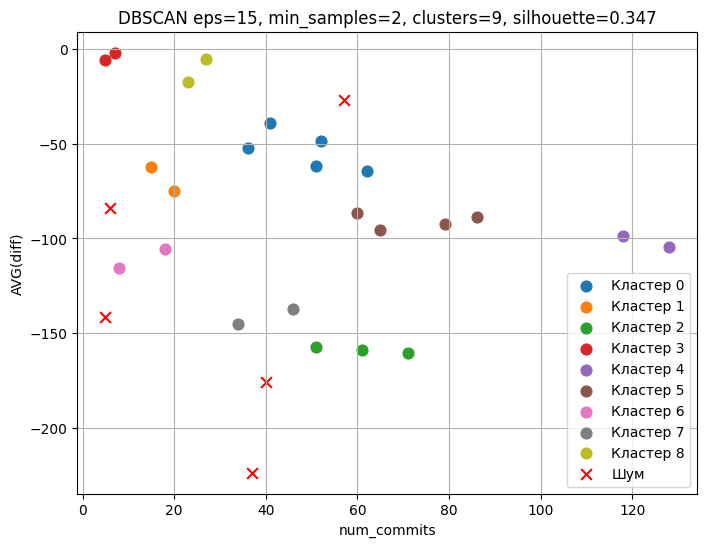

eps=15, min_samples=3, clusters=3, noise=17, silhouette_score=-0.006


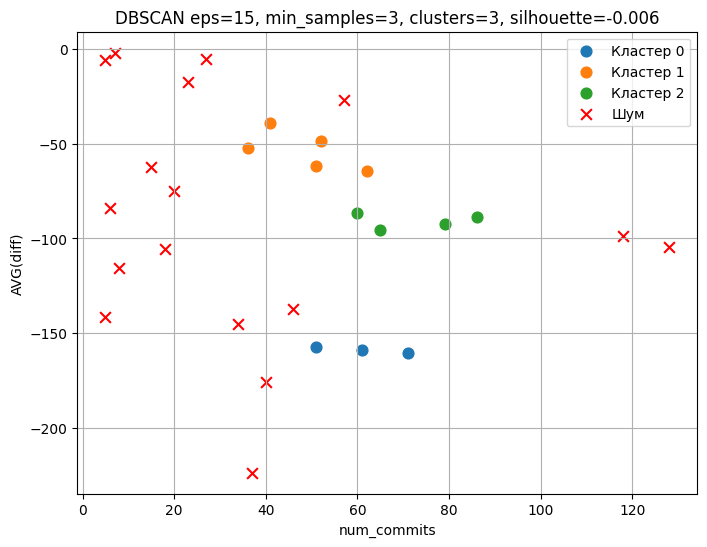

eps=15, min_samples=4, clusters=0, noise=29, silhouette_score=N/A


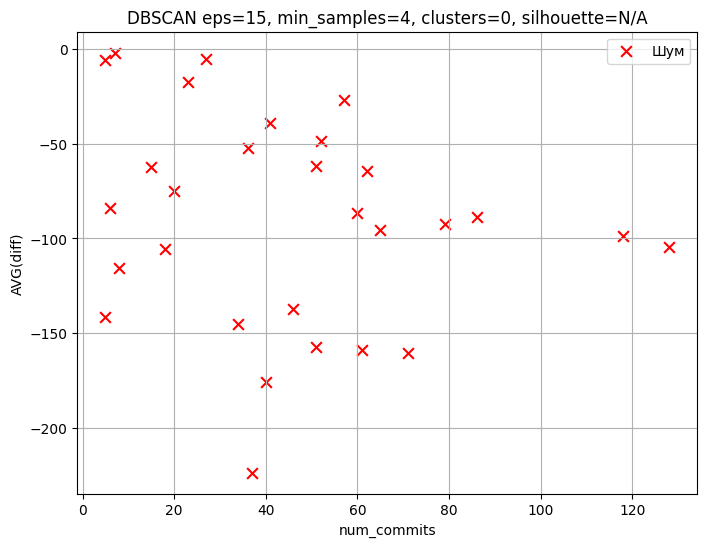

eps=15, min_samples=5, clusters=0, noise=29, silhouette_score=N/A


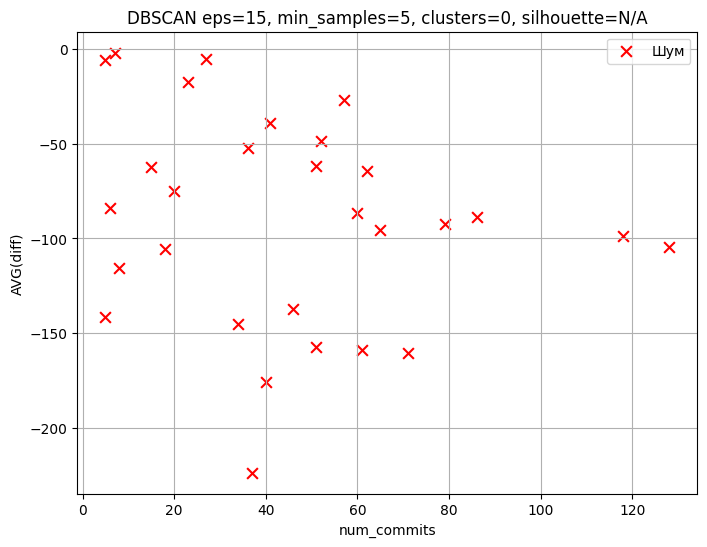

eps=20, min_samples=2, clusters=9, noise=4, silhouette_score=0.383


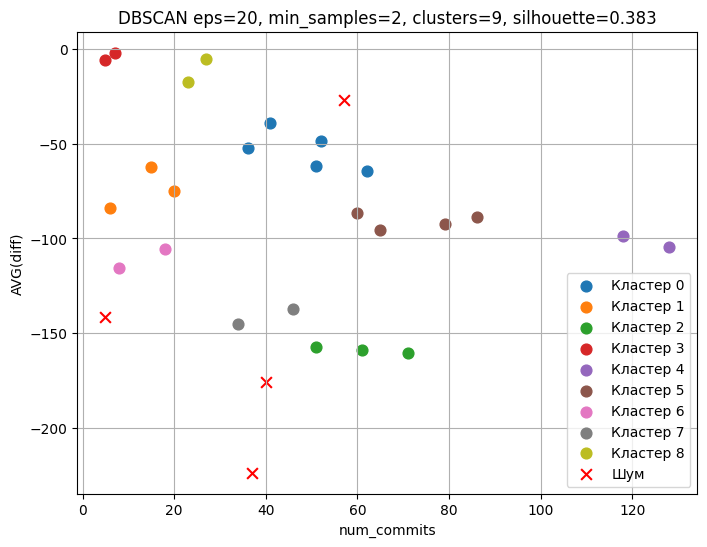

eps=20, min_samples=3, clusters=4, noise=14, silhouette_score=0.047


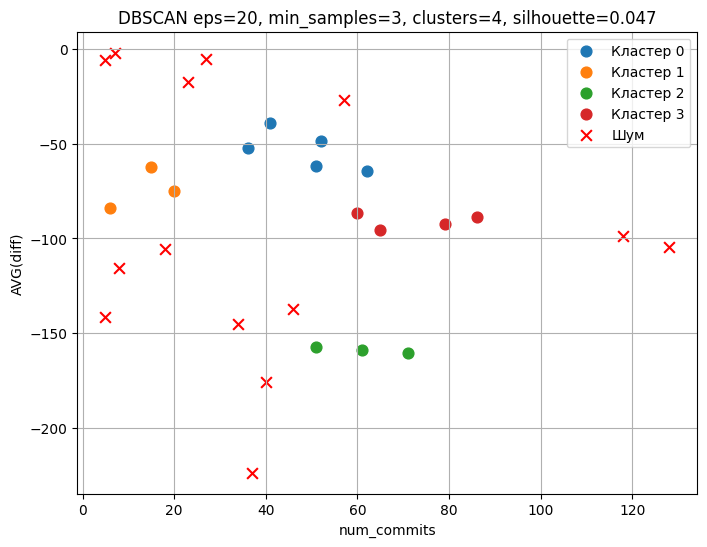

eps=20, min_samples=4, clusters=2, noise=20, silhouette_score=-0.027


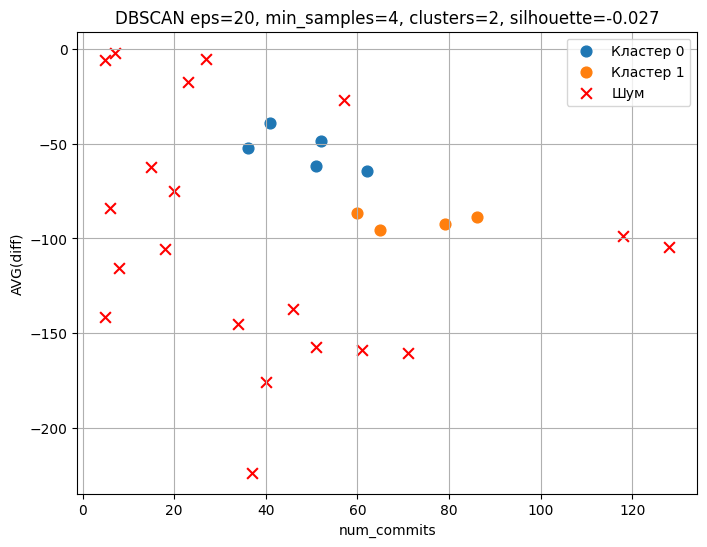

eps=20, min_samples=5, clusters=1, noise=24, silhouette_score=N/A


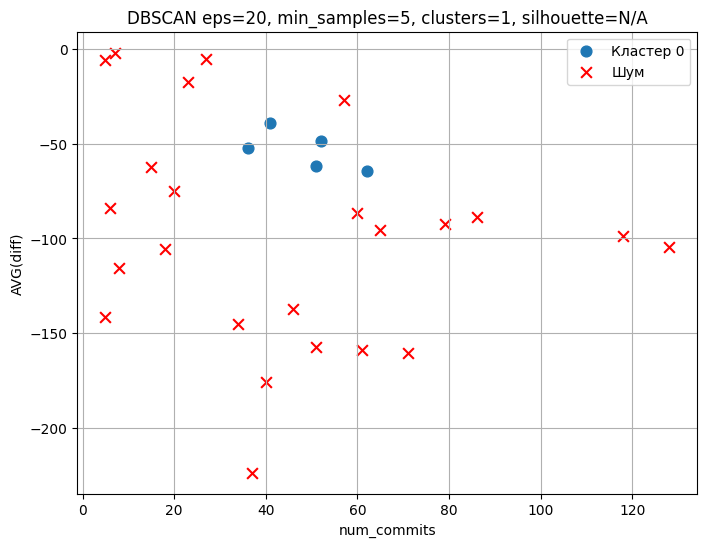

eps=25, min_samples=2, clusters=4, noise=2, silhouette_score=0.344


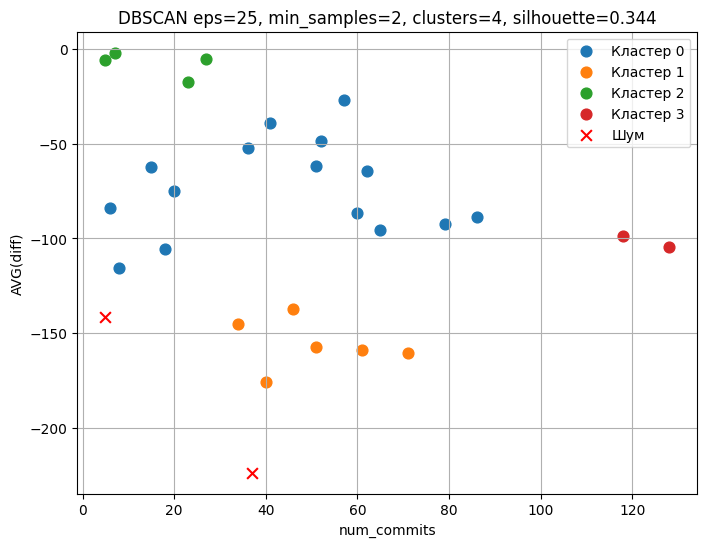

eps=25, min_samples=3, clusters=3, noise=4, silhouette_score=0.323


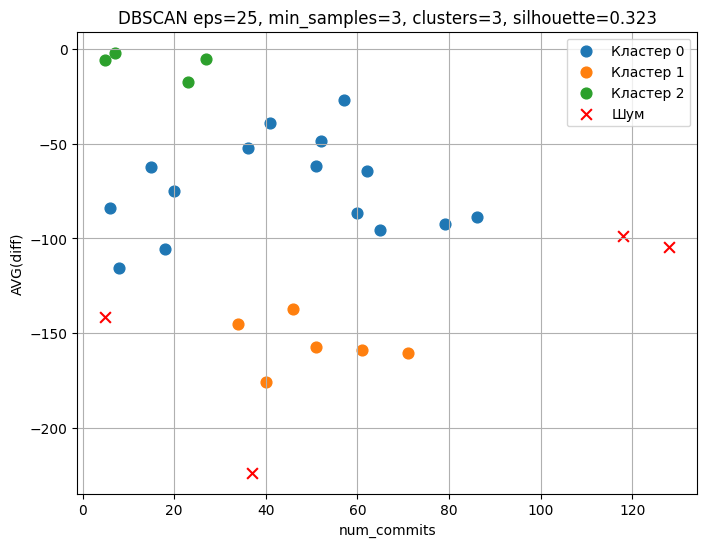

eps=25, min_samples=4, clusters=3, noise=5, silhouette_score=0.321


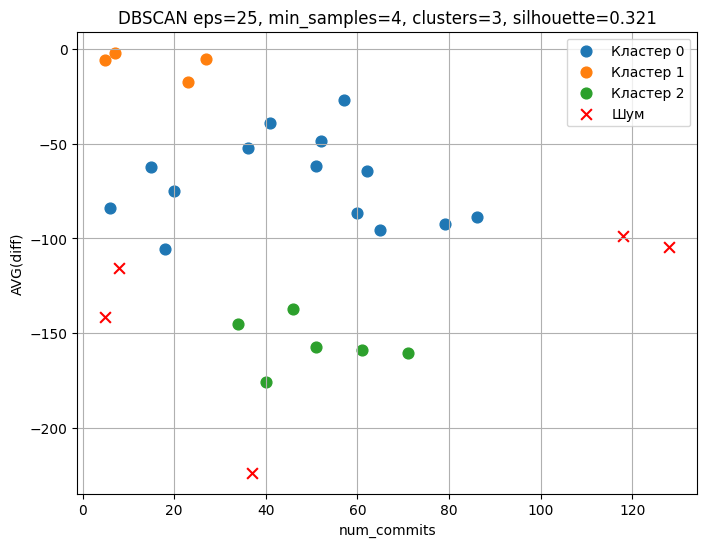

eps=25, min_samples=5, clusters=2, noise=16, silhouette_score=0.123


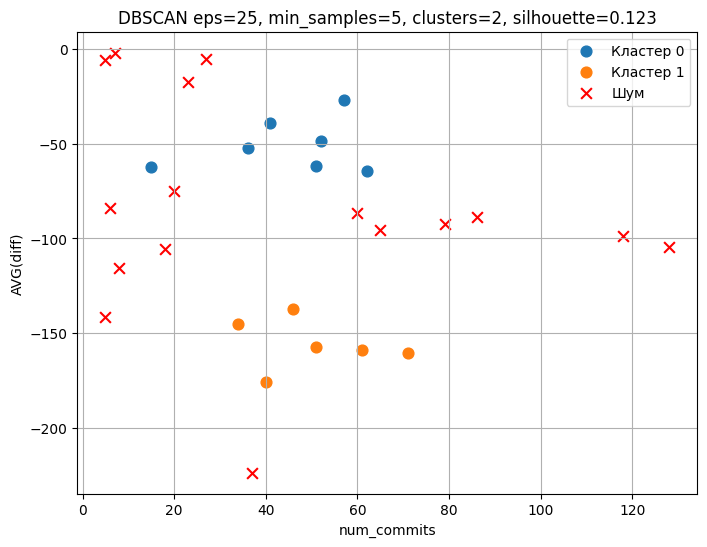

eps=30, min_samples=2, clusters=2, noise=1, silhouette_score=0.199


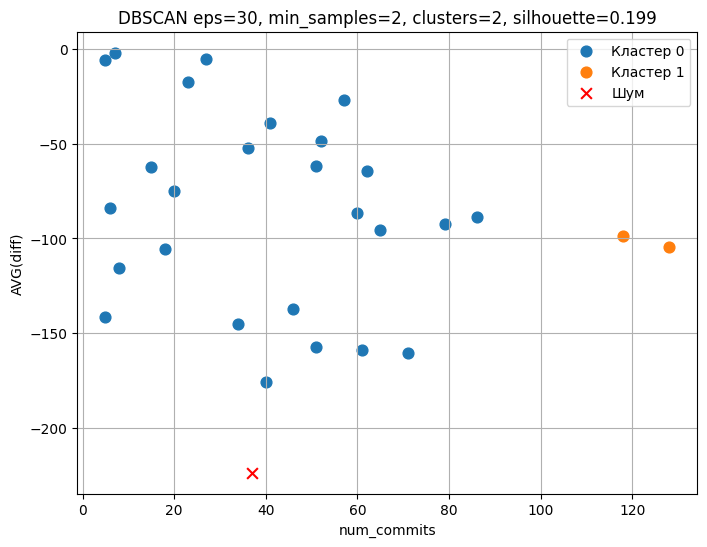

eps=30, min_samples=3, clusters=1, noise=3, silhouette_score=N/A


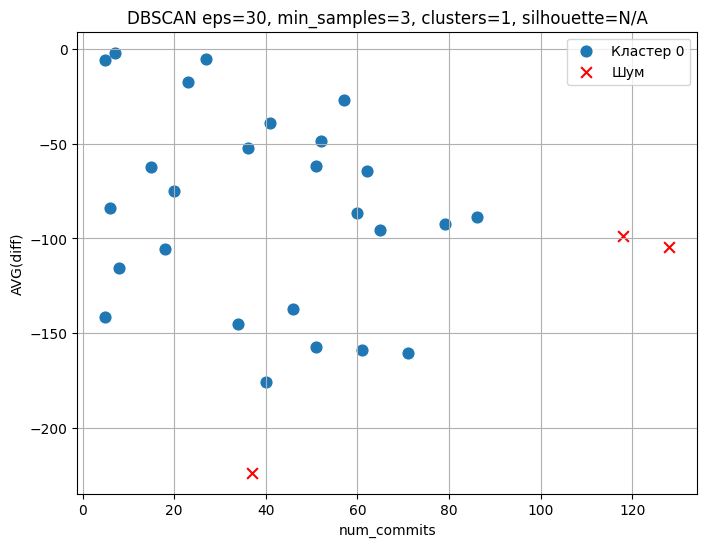

eps=30, min_samples=4, clusters=2, noise=4, silhouette_score=0.379


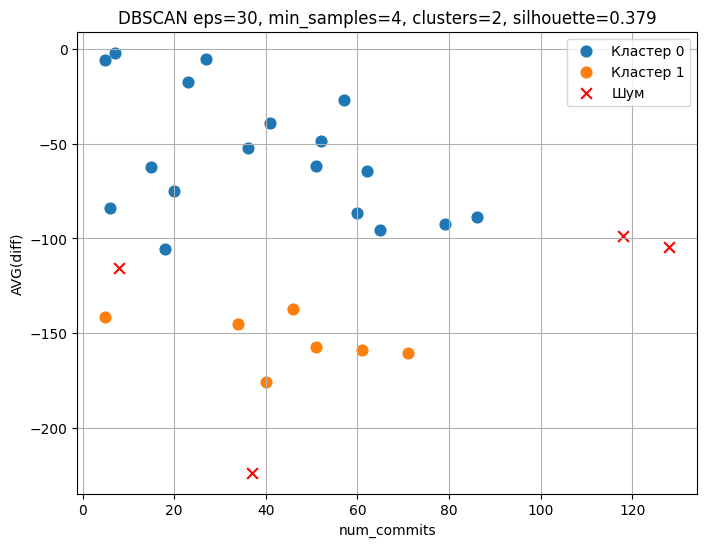

eps=30, min_samples=5, clusters=2, noise=7, silhouette_score=0.322


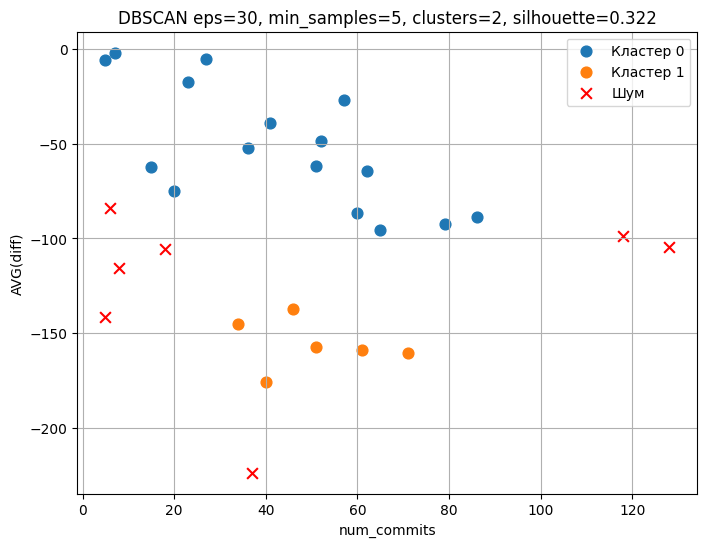

In [11]:
eps_list = [5, 10, 15, 20, 25, 30]
min_samples_list = [2, 3, 4, 5]

results = []

for eps in eps_list:
    for min_samples in min_samples_list:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(X, labels)
            score_str = f"{score:.3f}"
        else:
            score_str = "N/A"

        results.append((eps, min_samples, n_clusters, n_noise, score_str))
        
        print(f"eps={eps}, min_samples={min_samples}, "
              f"clusters={n_clusters}, noise={n_noise}, silhouette_score={score_str}")
        
        plt.figure(figsize=(8, 6))
        unique_labels = set(labels)
        colormap = plt.colormaps['viridis']
        colors = colormap(np.linspace(0, 1, len(unique_labels)))

        for k in unique_labels:
            class_member_mask = (labels == k)
            xy = X[class_member_mask]
            if k == -1:
                
                plt.scatter(xy[:, 0], xy[:, 1], c='red', marker='x', s=60, label='Шум')
            else:
                plt.scatter(xy[:, 0], xy[:, 1], s=60, label=f'Кластер {k}')

        plt.title(f'DBSCAN eps={eps}, min_samples={min_samples}, clusters={n_clusters}, silhouette={score_str}')
        plt.xlabel('num_commits')
        plt.ylabel('AVG(diff)')
        plt.grid(True)
        plt.legend()
        plt.show()

## 4. Иерархическая кластеризация (AgglomerativeClustering)

1. Используй этот алгоритм для создания кластеров с параметром `n_clusters=5`.
2. Визуализируй данные на `scatter plot`.
3. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
4. Вычисли `silhouette_score`.
5. Визуализируй `dendrogram`.

Silhouette Score: 0.464


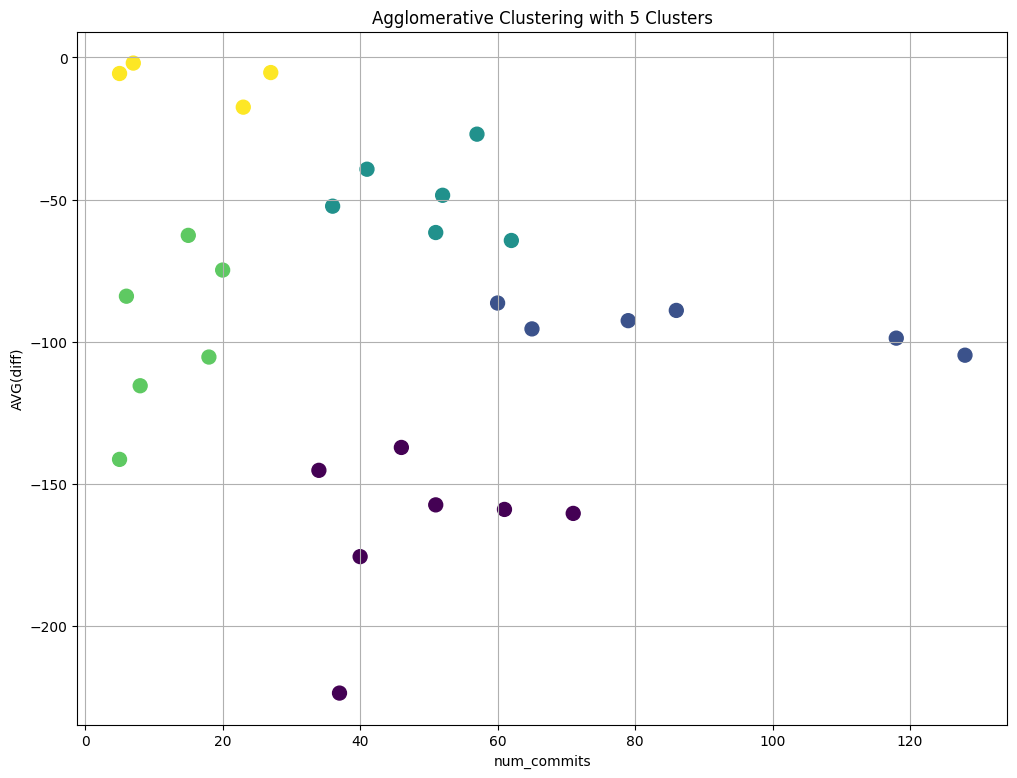

In [12]:
agg = AgglomerativeClustering(n_clusters=5)
labels = agg.fit_predict(X)
df['AG_cluster'] = labels

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")

plt.figure(figsize=(12, 9))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('Agglomerative Clustering with 5 Clusters')
plt.grid(True)
plt.show()

n_clusters = 2, Silhouette Score = 0.359, Clusters: 2


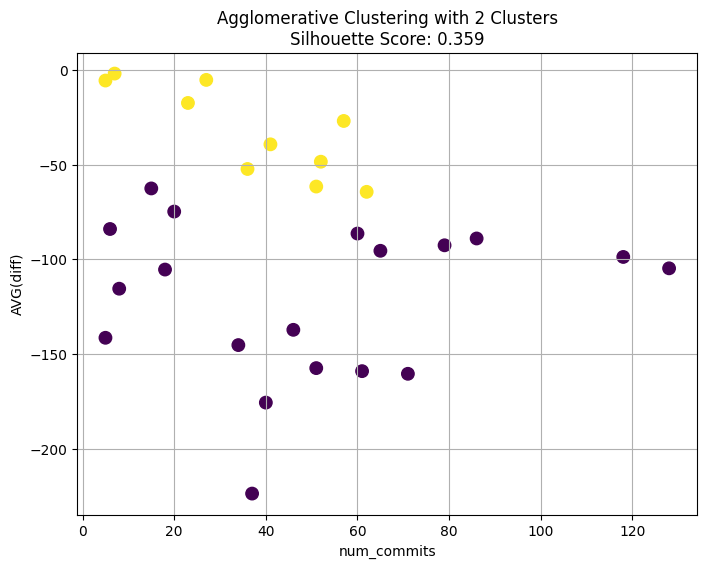

n_clusters = 3, Silhouette Score = 0.339, Clusters: 3


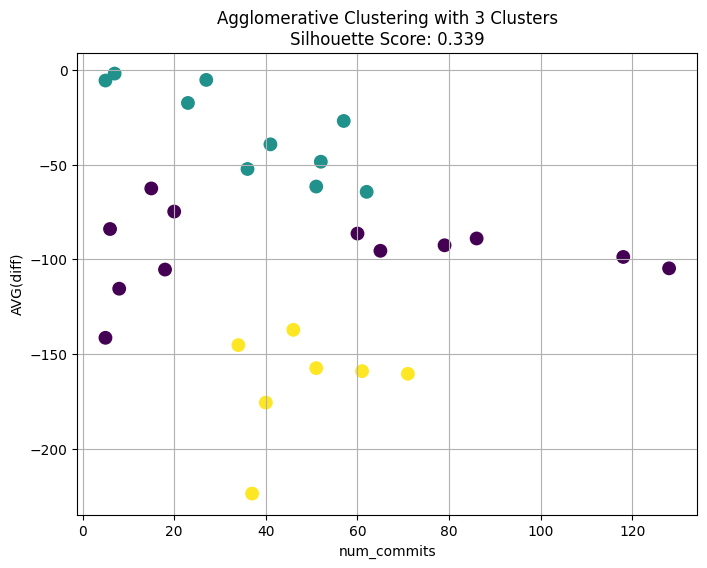

n_clusters = 4, Silhouette Score = 0.445, Clusters: 4


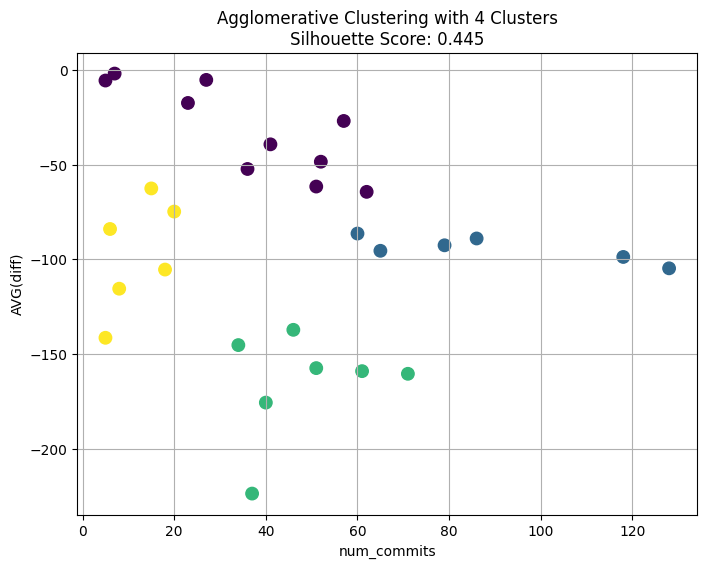

n_clusters = 5, Silhouette Score = 0.464, Clusters: 5


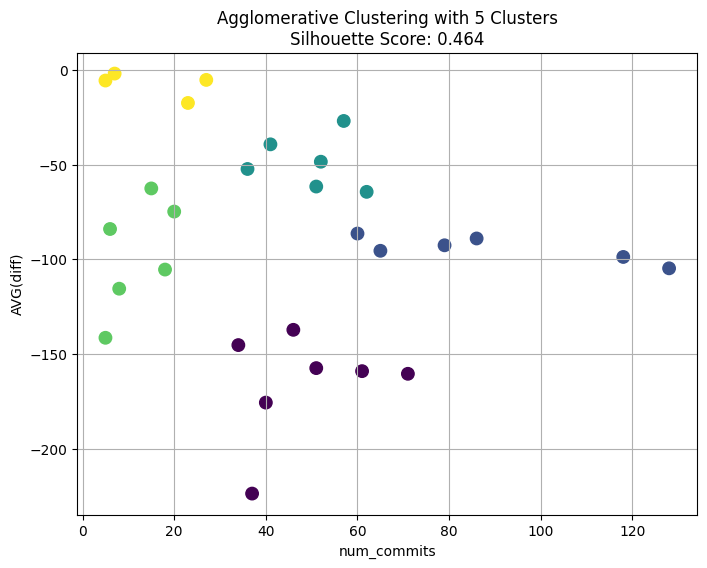

n_clusters = 6, Silhouette Score = 0.453, Clusters: 6


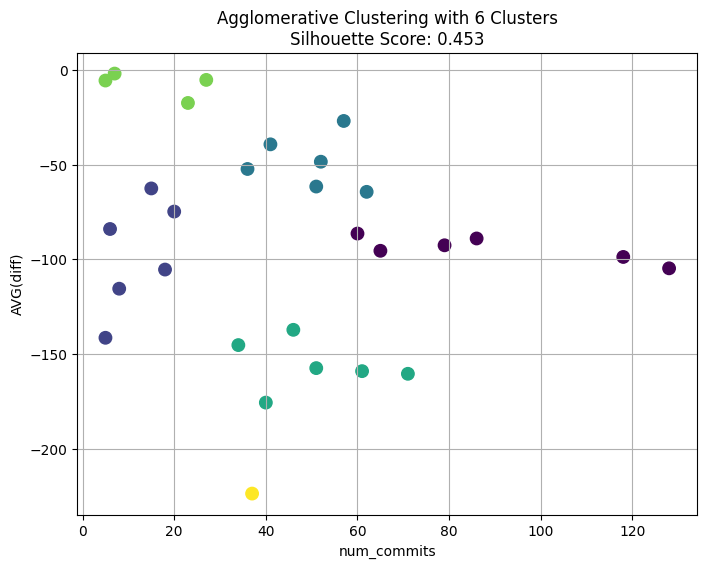

In [13]:
n_clusters_list = [2, 3, 4, 5, 6]

for k in n_clusters_list:

    agg = AgglomerativeClustering(n_clusters=k)
    

    labels = agg.fit_predict(X)

    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)
        score_str = f"{score:.3f}"
    else:
        score_str = "N/A"
    

    print(f"n_clusters = {k}, Silhouette Score = {score_str}, Clusters: {len(set(labels))}")

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=80)
    plt.title(f'Agglomerative Clustering with {k} Clusters\nSilhouette Score: {score_str}')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.grid(True)
    plt.show()

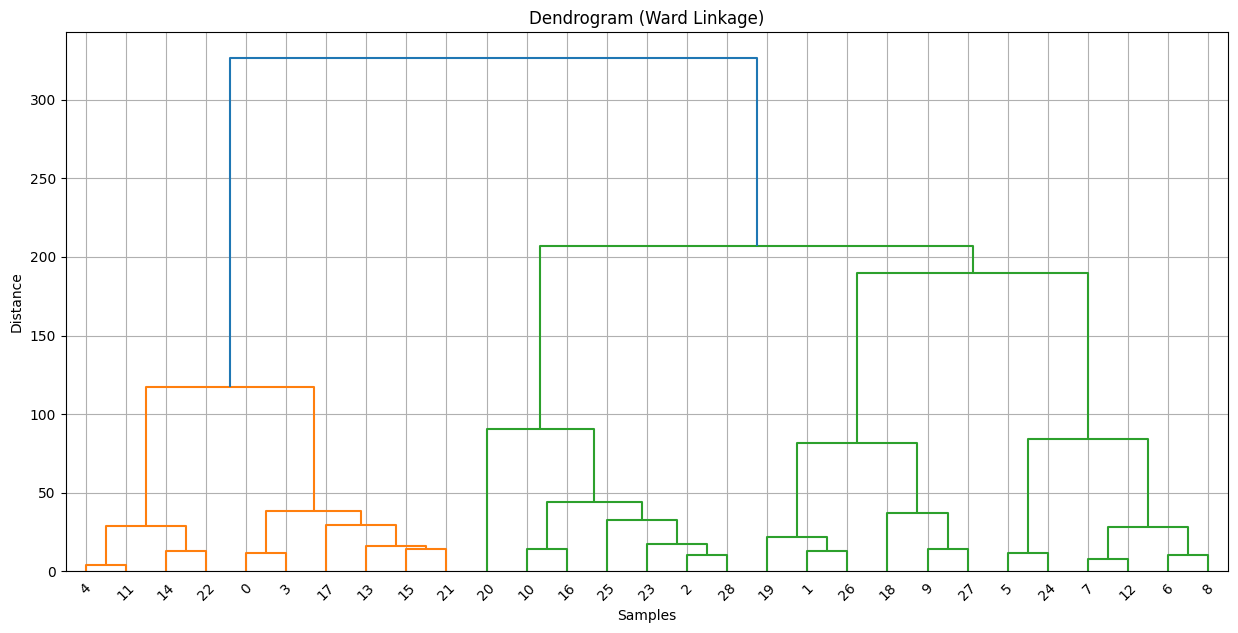

In [14]:
plt.figure(figsize=(15, 7))
dendro = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

## 5. Функция

Напиши функцию, которая:
1. Принимает аргументы: класс модели кластеризации, её параметры, имя параметра для оптимизации и диапазон значений этого параметра.
2. Перебирает разные значения из заданного диапазона и вычисляет `silhouette_score` для каждого значения.
3. Определяет лучшее значение параметра в диапазоне.
4. Возвращает два подграфика:

- первый показывает, как `silhouette_score` меняется в зависимости от значения параметра;
- второй визуализирует данные на `scatter plot` с использованием модели кластеризации с лучшим найденным значением параметра.

In [15]:
def optimize_cluster_param(model_class, base_params, param_name, param_range, X):
    scores = []
    labels_list = []
    
    for param_value in param_range:
        # Обновляем параметр
        params = base_params.copy()
        params[param_name] = param_value
        
        # Инициализируем и обучаем модель
        model = model_class(**params)
        labels = model.fit_predict(X)
        
        # Считаем silhouette_score
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1  # плохое разделение
        scores.append(score)
        labels_list.append(labels)
        
        print(f"{param_name}={param_value} ➔ silhouette_score={score:.3f}, clusters={len(set(labels))}")
    
    # Находим лучшее значение параметра
    best_idx = np.argmax(scores)
    best_param = param_range[best_idx]
    best_labels = labels_list[best_idx]
    
    print(f"\n✅ Best {param_name} = {best_param}, silhouette_score = {scores[best_idx]:.3f}")
    
    # Построение графиков
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 1️⃣ График silhouette_score vs param_value
    axes[0].plot(param_range, scores, marker='o')
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title(f'Silhouette Score vs {param_name}')
    axes[0].grid(True)
    
    # 2️⃣ Scatter plot кластеров при лучшем параметре
    scatter = axes[1].scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', s=60)
    axes[1].set_xlabel('num_commits')
    axes[1].set_ylabel('AVG(diff)')
    axes[1].set_title(f'Best {param_name} = {best_param}')
    axes[1].grid(True)
    
    plt.colorbar(scatter, ax=axes[1], label='Cluster Label')
    plt.tight_layout()
    plt.show()
    
    return best_param, scores

n_clusters=2 ➔ silhouette_score=0.419, clusters=2
n_clusters=3 ➔ silhouette_score=0.445, clusters=3
n_clusters=4 ➔ silhouette_score=0.415, clusters=4
n_clusters=5 ➔ silhouette_score=0.352, clusters=5
n_clusters=6 ➔ silhouette_score=0.395, clusters=6
n_clusters=7 ➔ silhouette_score=0.396, clusters=7
n_clusters=8 ➔ silhouette_score=0.486, clusters=8

✅ Best n_clusters = 8, silhouette_score = 0.486


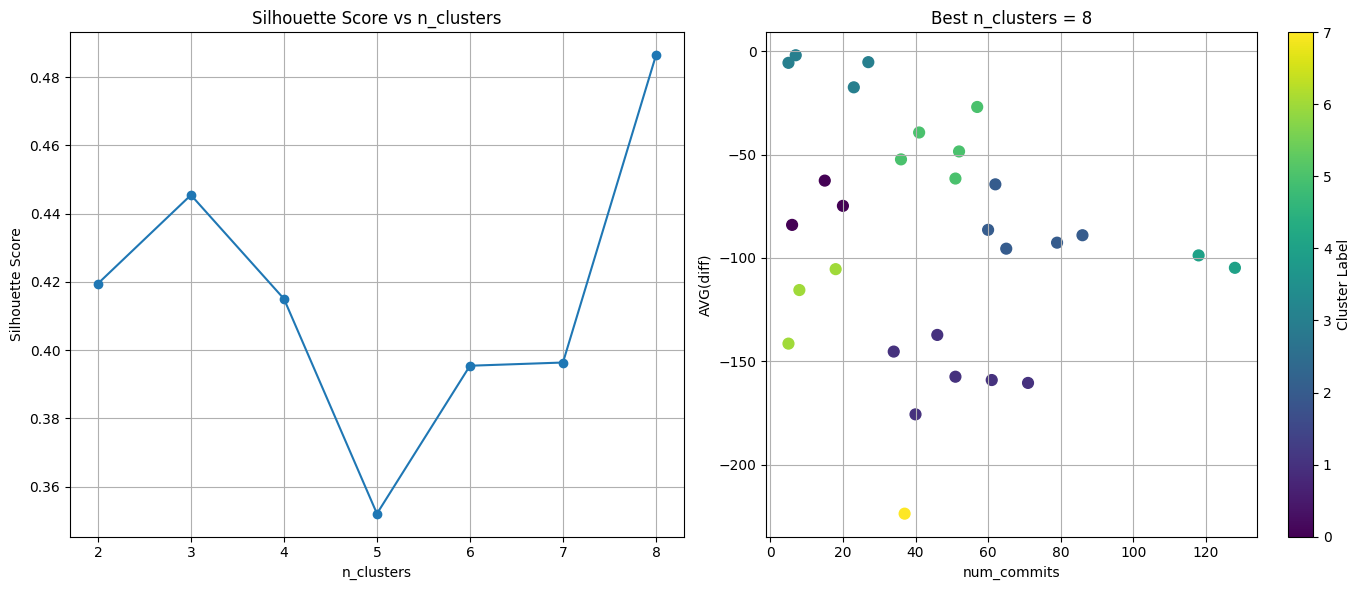

In [16]:
param_range = [2, 3, 4, 5, 6, 7, 8]
best_k, scores = optimize_cluster_param(KMeans, {'random_state': 21}, 'n_clusters', param_range, X)

eps=5 ➔ silhouette_score=-1.000, clusters=1
eps=10 ➔ silhouette_score=-1.000, clusters=1
eps=15 ➔ silhouette_score=-0.006, clusters=4
eps=20 ➔ silhouette_score=0.047, clusters=5
eps=22 ➔ silhouette_score=0.360, clusters=6
eps=25 ➔ silhouette_score=0.323, clusters=4
eps=30 ➔ silhouette_score=0.294, clusters=2

✅ Best eps = 22, silhouette_score = 0.360


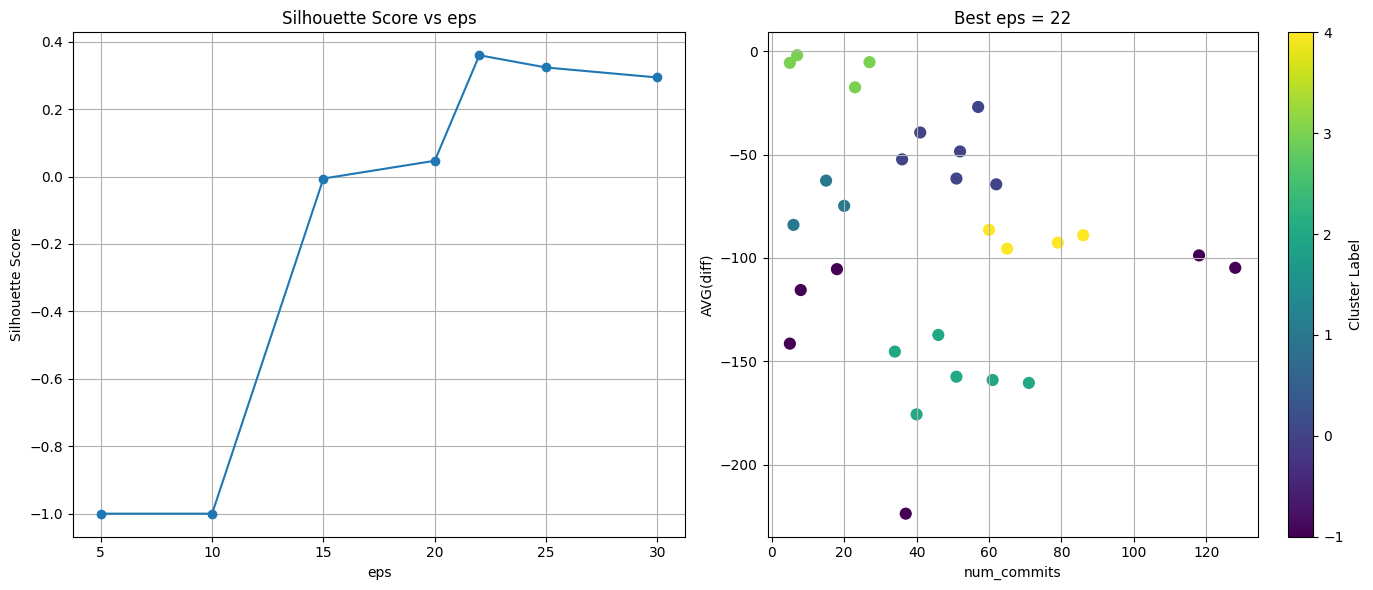

In [17]:
param_range = [5, 10, 15, 20, 22, 25, 30]
best_eps, scores = optimize_cluster_param(DBSCAN, {'min_samples': 3}, 'eps', param_range, X)

n_clusters=2 ➔ silhouette_score=0.359, clusters=2
n_clusters=3 ➔ silhouette_score=0.339, clusters=3
n_clusters=4 ➔ silhouette_score=0.445, clusters=4
n_clusters=5 ➔ silhouette_score=0.464, clusters=5
n_clusters=6 ➔ silhouette_score=0.453, clusters=6
n_clusters=7 ➔ silhouette_score=0.487, clusters=7
n_clusters=8 ➔ silhouette_score=0.508, clusters=8

✅ Best n_clusters = 8, silhouette_score = 0.508


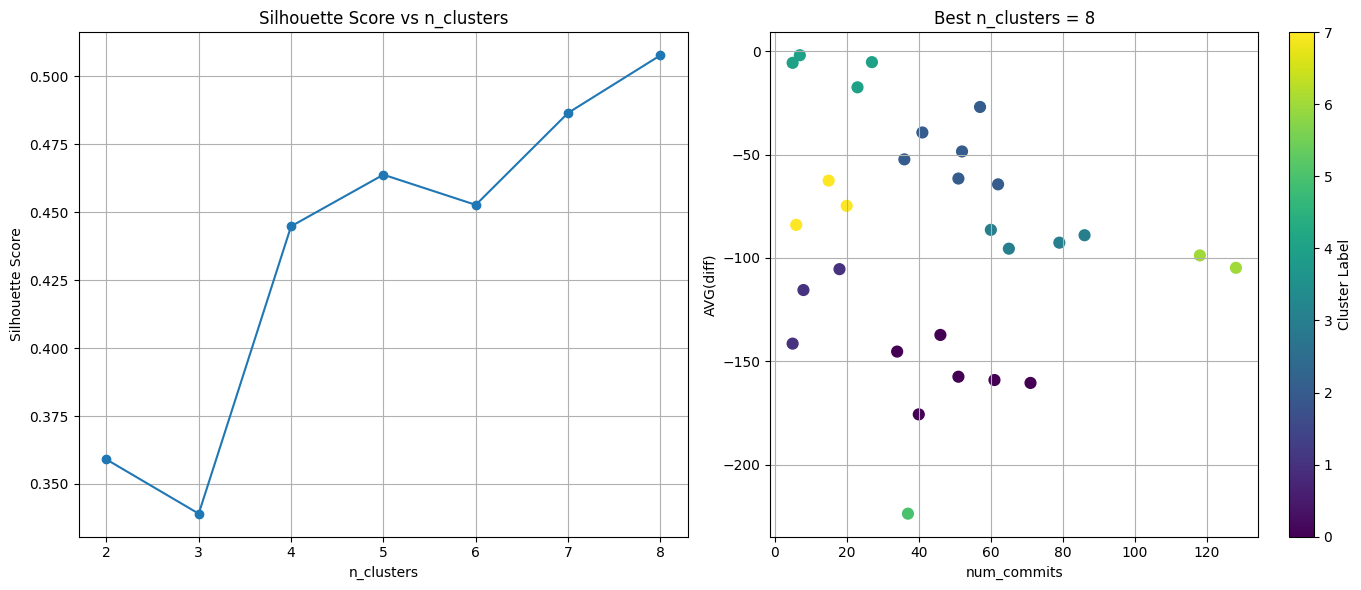

In [18]:
param_range = [2, 3, 4, 5, 6, 7, 8]
best_k, scores = optimize_cluster_param(AgglomerativeClustering, {}, 'n_clusters', param_range, X)